In [226]:
from skimage.util import random_noise
import skimage.io as io
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [227]:
image_path = 'image.png'

In [228]:
image = io.imread(image_path)
# 'mode' can be 'gaussian', 's&p', 'poisson', or 'speckle'
# 2. Generate different types of noise
gaussian_img = random_noise(image, mode='gaussian', var=0.01)
sp_img = random_noise(image, mode='s&p', amount=0.05)
speckle_img = random_noise(image, mode='speckle', mean=0, var=0.05)
blurred = cv2.GaussianBlur(image, (15, 15), 0)
poisson = random_noise(image, mode='poisson')

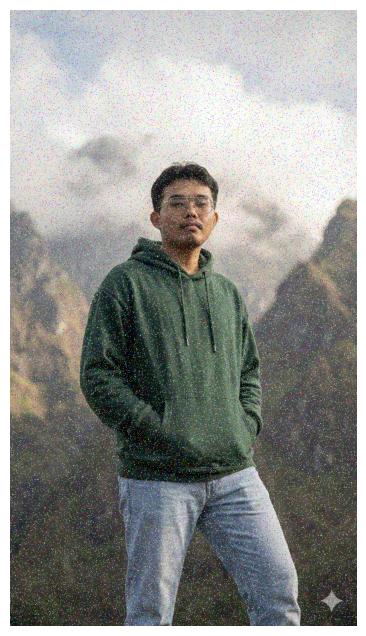

In [229]:
plt.figure(figsize=(8, 8))
plt.imshow(sp_img)

plt.axis('off') # Hides the x and y pixel coordinates

plt.show()

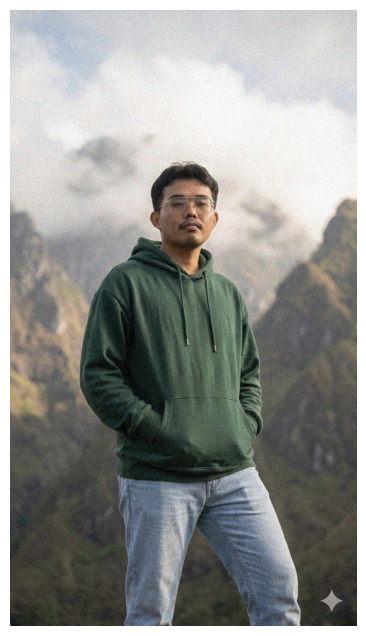

In [230]:
# Create the plot
plt.figure(figsize=(8, 8))
plt.imshow(poisson)

plt.axis('off') # Hides the x and y pixel coordinates

plt.show()

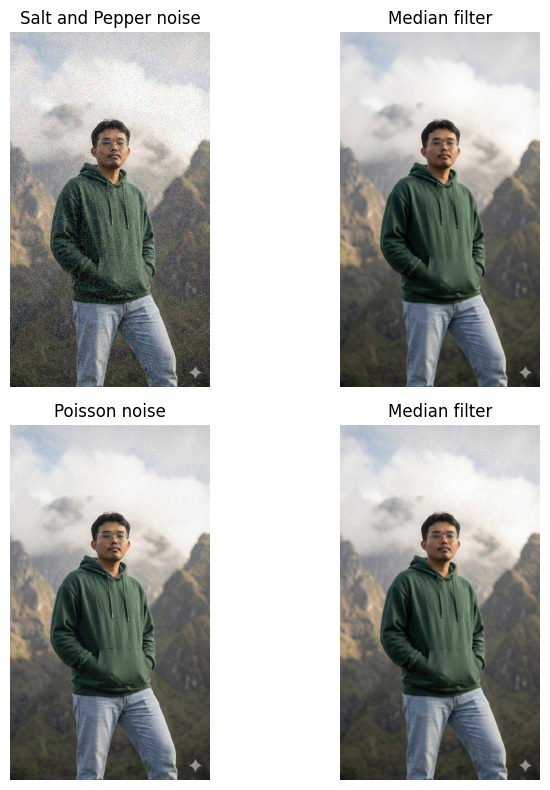

In [231]:
sp_img_32 = sp_img.astype(np.float32)
sp_median_denoise = cv2.medianBlur(sp_img_32, 5)

poisson_img_32 = poisson.astype(np.float32)
poisson_median_denoise = cv2.medianBlur(poisson_img_32, 5)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
axes[0][0].imshow(sp_img_32)
axes[0][0].set_title('Salt and Pepper noise')
axes[0][1].imshow(sp_median_denoise)
axes[0][1].set_title('Median filter')
axes[1][0].imshow(poisson_img_32)
axes[1][0].set_title('Poisson noise')
axes[1][1].imshow(poisson_median_denoise)
axes[1][1].set_title('Median filter')
for row in axes:
    for ax in row:
        ax.axis('off')
plt.tight_layout()
plt.show()

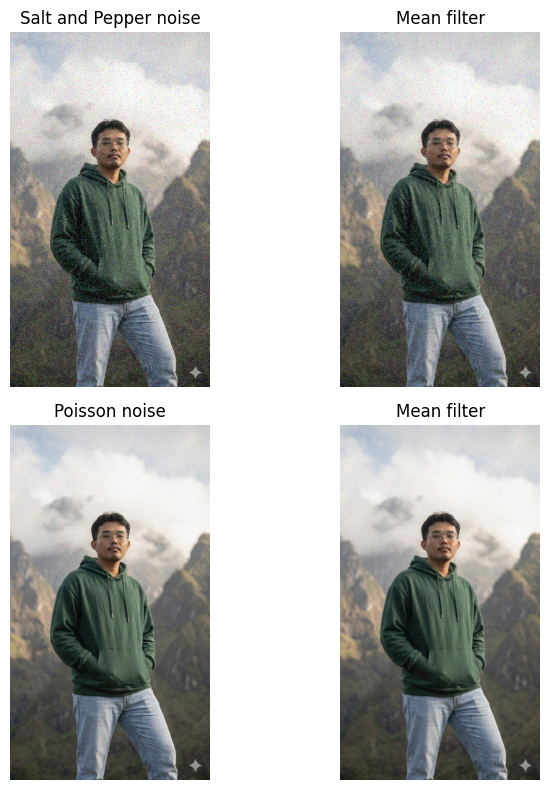

In [232]:
sp_img_32 = sp_img.astype(np.float32)
sp_mean_denoise = cv2.blur(sp_img_32, (3, 3))

poisson_img_32 = poisson.astype(np.float32)
poisson_mean_denoise = cv2.blur(poisson_img_32,(3, 3))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
axes[0][0].imshow(sp_img_32)
axes[0][0].set_title('Salt and Pepper noise')
axes[0][1].imshow(sp_mean_denoise)
axes[0][1].set_title('Mean filter')
axes[1][0].imshow(poisson_img_32)
axes[1][0].set_title('Poisson noise')
axes[1][1].imshow(poisson_mean_denoise)
axes[1][1].set_title('Mean filter')
for row in axes:
    for ax in row:
        ax.axis('off')
plt.tight_layout()
plt.show()

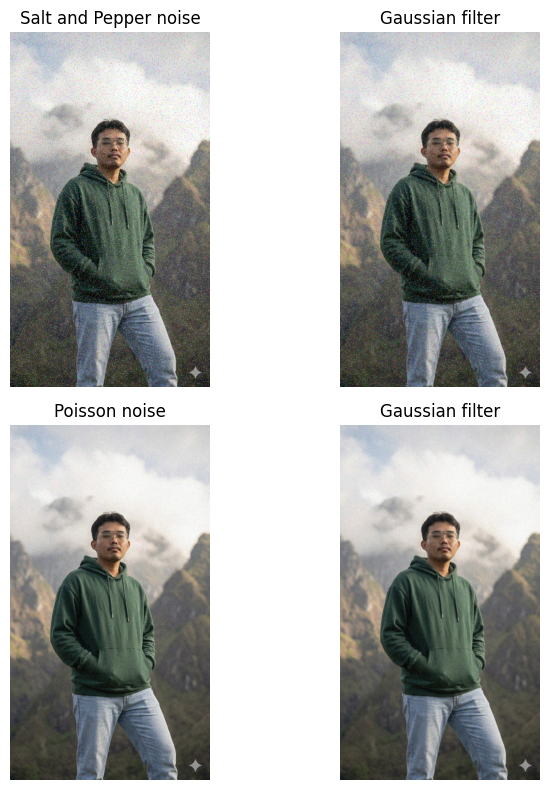

In [233]:
sp_img_32 = sp_img.astype(np.float32)
sp_gaussian_denoise = cv2.GaussianBlur(sp_img_32, (3, 3), 0)

poisson_img_32 = poisson.astype(np.float32)
poisson_gaussian_denoise = cv2.GaussianBlur(poisson_img_32, (3, 3), 0)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
axes[0][0].imshow(sp_img_32)
axes[0][0].set_title('Salt and Pepper noise')
axes[0][1].imshow(sp_gaussian_denoise)
axes[0][1].set_title('Gaussian filter')
axes[1][0].imshow(poisson_img_32)
axes[1][0].set_title('Poisson noise')
axes[1][1].imshow(poisson_gaussian_denoise)
axes[1][1].set_title('Gaussian filter')
for row in axes:
    for ax in row:
        ax.axis('off')
plt.tight_layout()
plt.show()

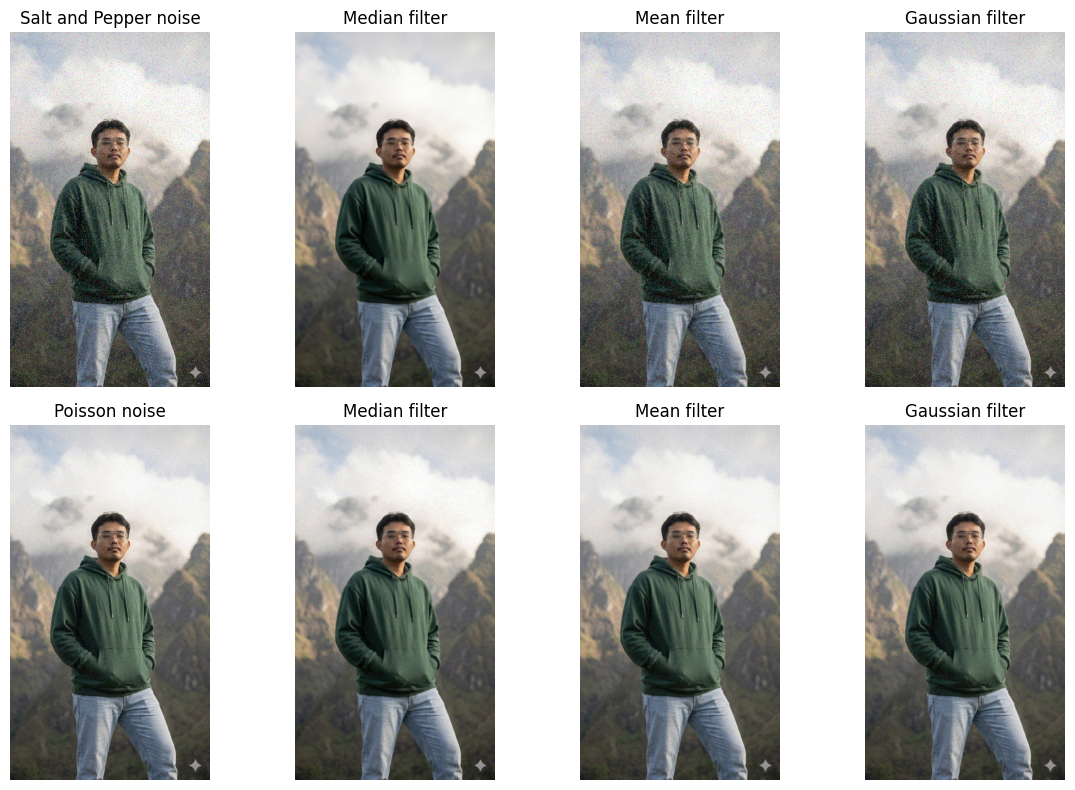

In [234]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
axes[0][0].imshow(sp_img_32)
axes[0][0].set_title('Salt and Pepper noise')
axes[0][1].imshow(sp_median_denoise)
axes[0][1].set_title('Median filter')
axes[0][2].imshow(sp_mean_denoise)
axes[0][2].set_title('Mean filter')
axes[0][3].imshow(sp_gaussian_denoise)
axes[0][3].set_title('Gaussian filter')
axes[1][0].imshow(poisson_img_32)
axes[1][0].set_title('Poisson noise')
axes[1][1].imshow(poisson_median_denoise)
axes[1][1].set_title('Median filter')
axes[1][2].imshow(poisson_mean_denoise)
axes[1][2].set_title('Mean filter')
axes[1][3].imshow(poisson_gaussian_denoise)
axes[1][3].set_title('Gaussian filter')
for row in axes:
    for ax in row:
        ax.axis('off')
plt.tight_layout()
plt.show()

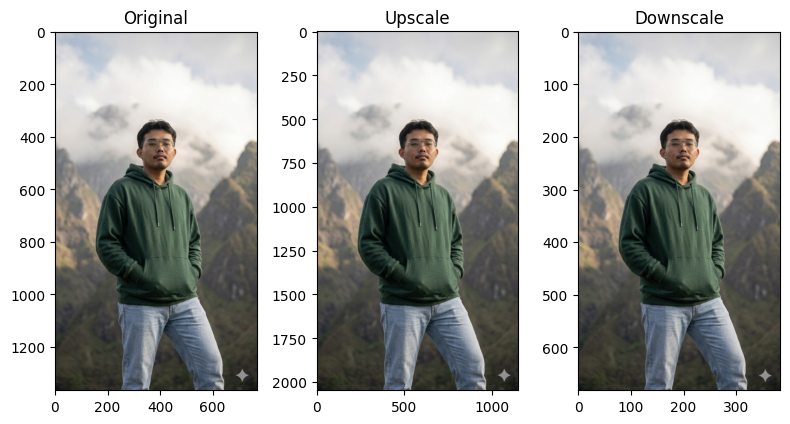

In [235]:
img = image.astype(np.float32)

downscale = cv2.resize(img, (0, 0), fx=0.5, fy=0.5)
upscale = cv2.resize(img, (0, 0), fx=1.5, fy=1.5)
img_normalized = img / 255.0
upscale_normalized = upscale / 255.0
downscale_normalized = downscale / 255.0

fig, axes = plt.subplots(ncols=3, figsize=(8, 8))
axes[0].imshow(img_normalized)
axes[0].set_title('Original')
axes[1].imshow(upscale_normalized)
axes[1].set_title('Upscale')
axes[2].imshow(downscale_normalized)
axes[2].set_title('Downscale')
plt.tight_layout()
plt.show()

In [236]:
import numpy as np
import cv2

# 1. Simple 0-1 Normalization (Min-Max)
img_01 = image.astype(np.float32) / 255.0

# 2. Standardization (Mean/Std)
mean = np.mean(img)
std = np.std(img)
img_standardized = (img - mean) / (std + 1e-7) # 1e-7 prevents division by zero

# 3. OpenCV's built-in normalize function
# This maps the min value to 0 and max value to 1
cv2_norm = cv2.normalize(img, None, alpha=0, beta=1, 
                         norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

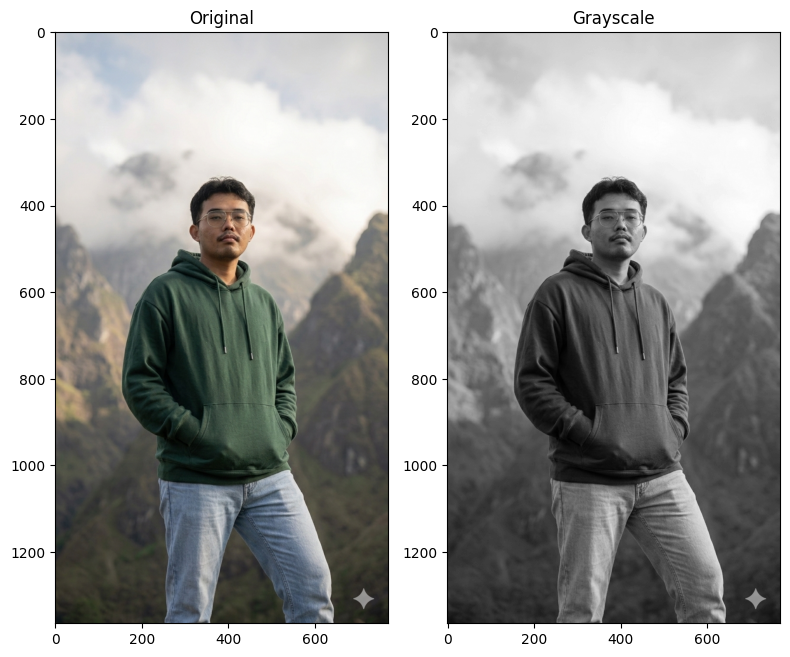

In [237]:
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread(image_path)
gray_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(ncols=2, figsize=(8, 8))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[1].imshow(gray_img, cmap='gray')
axes[1].set_title('Grayscale')
plt.tight_layout()
plt.show()

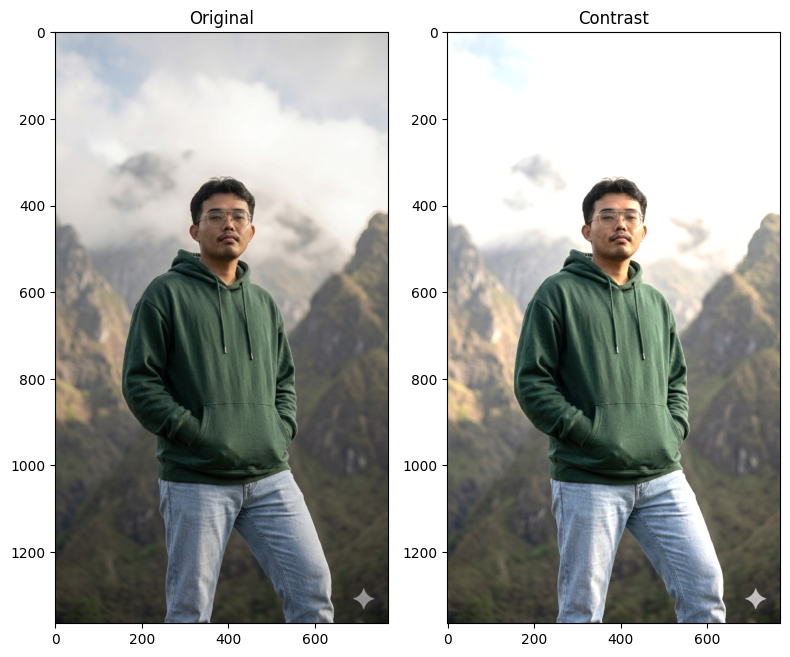

In [238]:
# Alpha (Contrast control): 1.0-3.0 is a good range.
# Beta (Brightness control): -100 to 100
alpha = 1.3
beta = 0.2

# Apply the formula: new_image = alpha * image + beta
# Use scaleAbs to handle rounding and saturation (clipping at 0 and 255) automatically.
contrast_stretched = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

fig, axes = plt.subplots(ncols=2, figsize=(8, 8))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[1].imshow(contrast_stretched)
axes[1].set_title('Contrast')
plt.tight_layout()
plt.show()

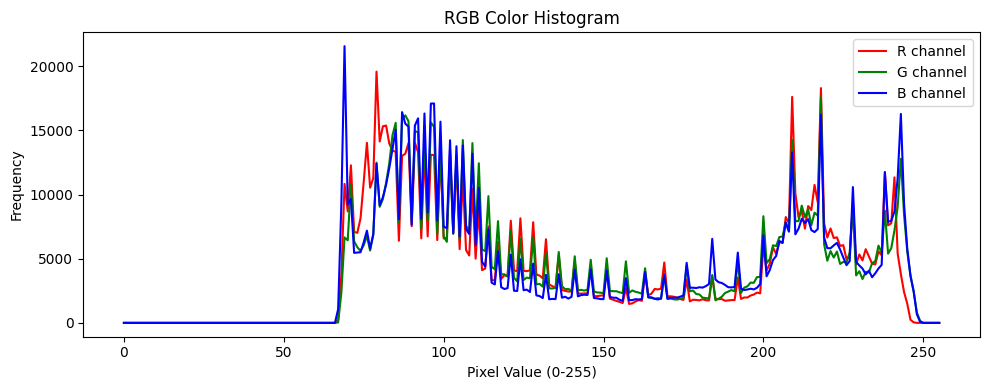

In [239]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("image2.png")
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plot histogram for each channel
colors = ('r', 'g', 'b')
plt.figure(figsize=(10, 4))

for i, color in enumerate(colors):
    hist = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=f'{color.upper()} channel')
    # plt.bar(range(256), hist.ravel(), color=color, alpha=0.5, width=1)

plt.title('RGB Color Histogram')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

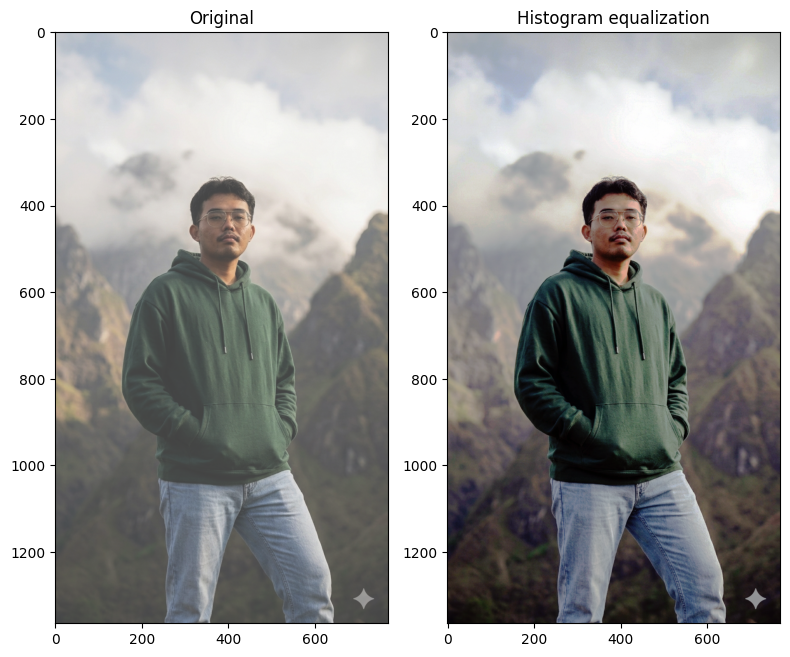

In [240]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

r, g, b = cv2.split(img_rgb)
r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)

img_eq = cv2.merge([r_eq, g_eq, b_eq])
fig, axes = plt.subplots(ncols=2, figsize=(8, 8))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[1].imshow(img_eq)
axes[1].set_title('Histogram equalization')
plt.tight_layout()
plt.show()

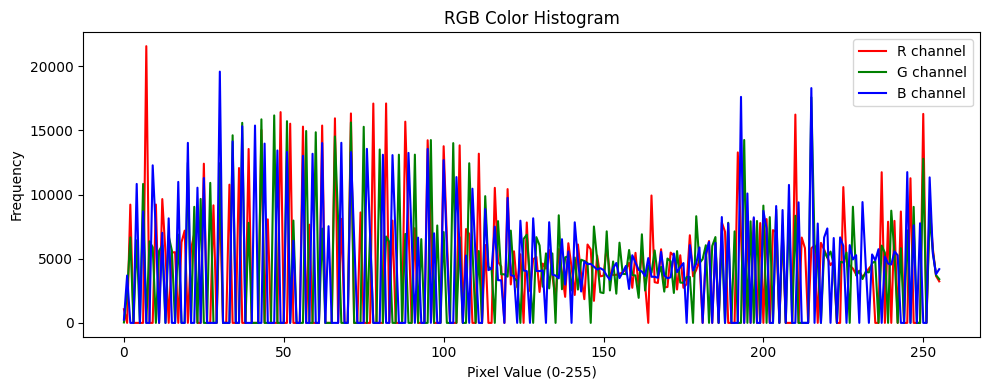

In [241]:
colors = ('r', 'g', 'b')
plt.figure(figsize=(10, 4))

for i, color in enumerate(colors):
    hist = cv2.calcHist([img_eq], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=f'{color.upper()} channel')
    # plt.bar(range(256), hist.ravel(), color=color, alpha=0.5, width=1)

plt.title('RGB Color Histogram')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()